# Laboratorio 4 — Cuaderno 12: interpretación y explicabilidad

**Ejercicio 8 de la Parte 2.**

XGBoost resultó el mejor modelo en el cuaderno 9 y mantuvo el liderazgo en PR-AUC bajo las
tres particiones del cuaderno 10. Aquí se abre para ver qué aprendió: qué variables usa,
cuánto pesa cada una y en qué dirección empuja la predicción.

El interés no es solo técnico. Si el modelo apoya sus decisiones en las variables que la
óptica del agua señalaría —el realce en el borde rojo, la absorción en el azul— entonces
está capturando el fenómeno físico. Si las apoyara en algo arbitrario, funcionaría
mientras las condiciones no cambien y fallaría en cuanto lo hicieran.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# shap importa tqdm.auto, que avisa si no encuentra ipywidgets. El aviso no
# afecta al calculo y ensuciaria la salida del cuaderno.
warnings.filterwarnings("ignore", message="IProgress not found")
import shap

from sklearn.inspection import permutation_importance

from src import config, ml

SEMILLA = 42
rng = np.random.default_rng(SEMILLA)

guardado = joblib.load(config.MODELOS / "modelos_division_aleatoria.joblib")
mejor = guardado["mejor"]
modelo = guardado["modelos"][mejor]
umbral = guardado["umbrales"][mejor]

print(f"Mejor modelo: {mejor}")
print(f"Umbral de decisión: {umbral}")
print(f"Predictoras: {len(ml.PREDICTORAS)}")

datos = pd.read_parquet(config.DERIVADO / "dataset_ml.parquet")
datos[ml.RESPUESTA] = ml.variable_respuesta(datos)
datos = ml.caracteristicas(datos)

# Se interpreta sobre el conjunto de prueba, que el modelo no vio al entrenar.
prueba = datos.loc[guardado["idx_prueba"]]
X_prueba, y_prueba = prueba[ml.PREDICTORAS], prueba[ml.RESPUESTA]
print(f"\nConjunto de prueba: {len(prueba):,} observaciones, "
      f"{int(y_prueba.sum()):,} positivos")

Mejor modelo: XGBoost
Umbral de decisión: 0.99
Predictoras: 16



Conjunto de prueba: 1,127,737 observaciones, 13,305 positivos


## 8.1 Importancia global de las variables predictoras

Se calculan dos medidas, porque miden cosas distintas y conviene contrastarlas.

**Ganancia** es la medida interna de XGBoost: cuánto mejora la función de pérdida cada vez
que un árbol corta por esa variable. Es gratis de calcular pero tiene un sesgo conocido —
reparte mal el crédito entre variables correlacionadas, y aquí hay muchas: `B07` y
`nd_borde_verde` miden casi lo mismo, igual que `ndwi` y `mndwi`.

**Importancia por permutación** mide cuánto se degrada el PR-AUC cuando se barajan al azar
los valores de una variable sobre datos que el modelo no vio. Es más cara pero responde a
la pregunta que de verdad importa: *si perdiera este sensor, ¿cuánto empeoraría?*

In [2]:
ganancia = pd.Series(
    modelo.get_booster().get_score(importance_type="gain")
).reindex(ml.PREDICTORAS).fillna(0.0)
ganancia = (ganancia / ganancia.sum()).sort_values(ascending=False)

print("Importancia por ganancia (normalizada)\n")
for var, valor in ganancia.items():
    print(f"  {var:<18}{100*valor:6.2f} %  " + "#" * int(round(120 * valor)))

Importancia por ganancia (normalizada)

  B07                60.38 %  ########################################################################
  razon_azul_verde   15.09 %  ##################
  B08                11.33 %  ##############
  ndmi                4.75 %  ######
  nd_borde_verde      2.52 %  ###
  dist_orilla_m       1.04 %  #
  B03                 0.88 %  #
  B02                 0.85 %  #
  B8A                 0.60 %  #
  brillo_visible      0.55 %  #
  y                   0.49 %  #
  B12                 0.39 %  
  ndwi                0.37 %  
  mndwi               0.28 %  
  x                   0.26 %  
  B11                 0.23 %  


In [3]:
# La permutacion se hace sobre una submuestra estratificada: repetir 16 barajados
# sobre 1.1 millones de filas no cambiaria el orden y costaria mucho mas.
pos = prueba.index[y_prueba == 1]
neg = prueba.index[y_prueba == 0]
muestra = pos.union(pd.Index(rng.choice(neg, size=60000, replace=False)))

resultado_perm = permutation_importance(
    modelo, X_prueba.loc[muestra], y_prueba.loc[muestra],
    scoring="average_precision", n_repeats=5, random_state=SEMILLA, n_jobs=-1,
)

permutacion = pd.Series(
    resultado_perm.importances_mean, index=ml.PREDICTORAS
).sort_values(ascending=False)
desviacion = pd.Series(resultado_perm.importances_std, index=ml.PREDICTORAS)

print(f"Caída de PR-AUC al barajar cada variable ({len(muestra):,} observaciones, 5 repeticiones)\n")
for var, valor in permutacion.items():
    print(f"  {var:<18}{valor:+.4f} ± {desviacion[var]:.4f}  " + "#" * int(max(0, round(300 * valor))))

Caída de PR-AUC al barajar cada variable (73,305 observaciones, 5 repeticiones)

  nd_borde_verde    +0.0620 ± 0.0005  ###################
  razon_azul_verde  +0.0403 ± 0.0006  ############
  B07               +0.0212 ± 0.0009  ######
  ndmi              +0.0050 ± 0.0001  #
  B02               +0.0026 ± 0.0001  #
  B08               +0.0005 ± 0.0000  
  B12               +0.0004 ± 0.0000  
  x                 +0.0003 ± 0.0000  
  ndwi              +0.0003 ± 0.0000  
  y                 +0.0002 ± 0.0001  
  B03               +0.0002 ± 0.0000  
  mndwi             +0.0002 ± 0.0000  
  brillo_visible    +0.0001 ± 0.0000  
  dist_orilla_m     +0.0001 ± 0.0000  
  B11               +0.0001 ± 0.0000  
  B8A               -0.0000 ± 0.0000  


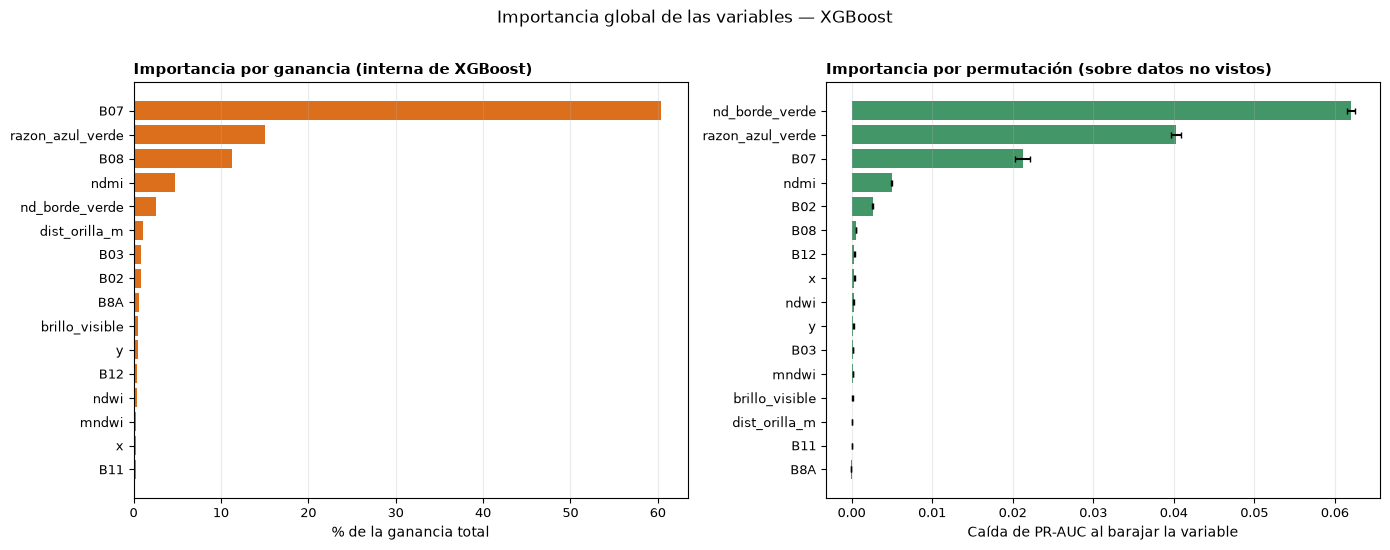

In [4]:
fig, ejes = plt.subplots(1, 2, figsize=(14, 5.4))

orden_g = ganancia.sort_values()
ejes[0].barh(orden_g.index, 100 * orden_g.values, color="#d95f02", alpha=0.9)
ejes[0].set_xlabel("% de la ganancia total")
ejes[0].set_title("Importancia por ganancia (interna de XGBoost)",
                  loc="left", fontsize=11, fontweight="bold")

orden_p = permutacion.sort_values()
ejes[1].barh(orden_p.index, orden_p.values,
             xerr=desviacion[orden_p.index].values, capsize=2, color="#2e8b57", alpha=0.9)
ejes[1].set_xlabel("Caída de PR-AUC al barajar la variable")
ejes[1].set_title("Importancia por permutación (sobre datos no vistos)",
                  loc="left", fontsize=11, fontweight="bold")

for eje in ejes:
    eje.grid(alpha=0.25, axis="x")
    eje.tick_params(labelsize=9)

fig.suptitle(f"Importancia global de las variables — {mejor}", y=1.01)
fig.tight_layout()
plt.show()

### Las dos medidas no coinciden, y la discrepancia es informativa

Por ganancia, `B07` se lleva el 60.38 % y `nd_borde_verde` apenas el 2.52 %. Por
permutación el orden se invierte: barajar `nd_borde_verde` cuesta 0.0620 de PR-AUC y
barajar `B07` solo 0.0212.

No es una contradicción, es el sesgo anunciado. `nd_borde_verde` es
$(B07-B03)/(B07+B03)$: contiene a `B07`. Cuando el árbol elige entre las dos para cortar,
la ganancia se la anota a la que usó, y suele usar la banda cruda porque aparece primero.
La permutación pregunta otra cosa: al barajar `B07`, el modelo todavía tiene
`nd_borde_verde` para recuperar buena parte de la señal, así que el daño es limitado. Al
barajar `nd_borde_verde` pierde la versión normalizada —la que cancela la iluminación de
la escena— y eso duele más.

**La lectura correcta es de grupos, no de variables sueltas.** Tres bloques concentran
todo: la señal de borde rojo (`B07` + `nd_borde_verde`), la razón azul/verde
(`razon_azul_verde` + `B02`) y el contraste infrarrojo (`ndmi`). El resto es marginal.

### Las variables espaciales casi no se usan

Este resultado merece señalarse porque cierra un hilo abierto en el cuaderno 10. Barajar
`x`, `y` o `dist_orilla_m` cuesta entre 0.0001 y 0.0003 de PR-AUC: prácticamente nada. El
modelo **no** predice mirando dónde está el píxel, predice mirando su espectro.

Eso explica por qué la validación espacial del cuaderno 10 apenas degradó el desempeño
(−0.0084 de F2) mientras que la temporal lo hundió (−0.1263). Un modelo que no usa la
posición no tiene nada que perder cuando se le retiene una zona entera. Y confirma que
`dist_orilla_m`, pese a la intuición ecológica que motivó construirla, aporta poco una vez
que el espectro está sobre la mesa: la cercanía a la orilla influye en que haya floración,
pero si la hay, el espectro ya lo dice.

## 8.2 SHAP

Las dos medidas anteriores dan un número por variable para todo el conjunto. SHAP va más
allá: reparte cada predicción individual entre las variables que la produjeron, de modo
que se puede ver no solo **cuánto** pesa una variable sino **en qué dirección** empuja y
si ese empuje depende del valor que tome.

Se usa `TreeExplainer`, que calcula los valores de Shapley de forma exacta para modelos de
árboles. Los valores están en unidades de log-odds: positivo empuja hacia "alta presencia",
negativo hacia "baja presencia".

In [5]:
# Muestra estratificada para SHAP. Con 1.18% de positivos, una muestra aleatoria
# simple dejaria el grafico dominado por negativos y no se veria nada de la clase
# que interesa; se toman 8000 de cada clase y se anota que la proporcion no es la
# poblacional.
n_clase = 8000
muestra_shap = np.concatenate([
    rng.choice(prueba.index[y_prueba == 1], size=n_clase, replace=False),
    rng.choice(prueba.index[y_prueba == 0], size=n_clase, replace=False),
])
X_shap = X_prueba.loc[muestra_shap]

explicador = shap.TreeExplainer(modelo)
valores_shap = explicador.shap_values(X_shap)

print(f"Valores SHAP calculados: {valores_shap.shape[0]:,} observaciones x "
      f"{valores_shap.shape[1]} variables")
print(f"Valor base (log-odds sin información): {explicador.expected_value:.3f}")

Valores SHAP calculados: 16,000 observaciones x 16 variables
Valor base (log-odds sin información): -0.313


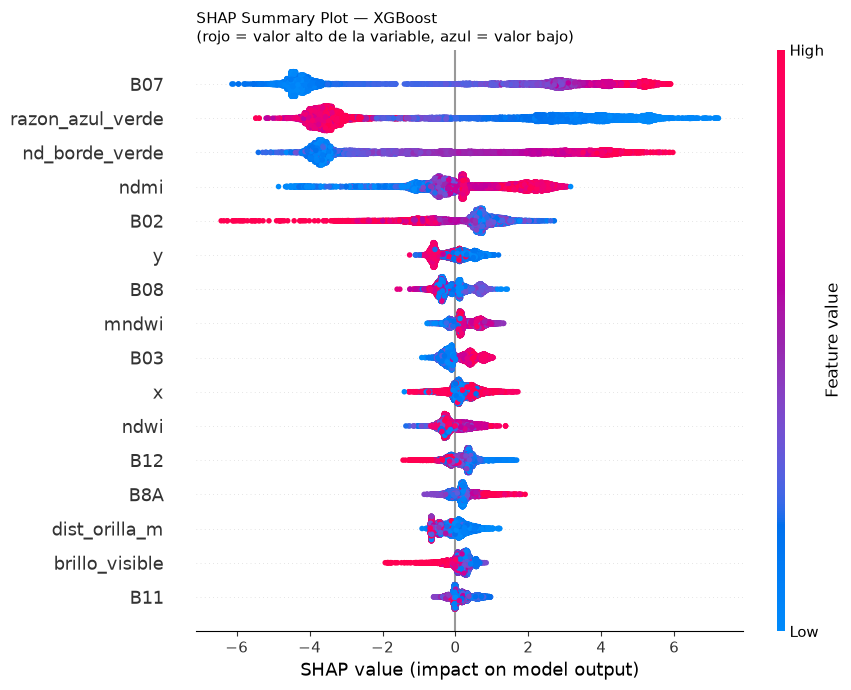

In [6]:
shap.summary_plot(valores_shap, X_shap, feature_names=ml.PREDICTORAS,
                  max_display=16, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 7)
plt.title("SHAP Summary Plot — XGBoost\n(rojo = valor alto de la variable, azul = valor bajo)",
          fontsize=11, loc="left")
plt.tight_layout()
plt.show()

In [7]:
importancia_shap = pd.Series(
    np.abs(valores_shap).mean(axis=0), index=ml.PREDICTORAS
).sort_values(ascending=False)

print("SHAP medio absoluto por variable (impacto promedio en log-odds)\n")
for var, valor in importancia_shap.items():
    print(f"  {var:<18}{valor:6.3f}  " + "#" * int(round(20 * valor)))

print("\nConcordancia entre las tres medidas (orden de las cinco primeras)\n")
print(f"{'ganancia':<20}{'permutación':<20}{'SHAP':<20}")
print("-" * 58)
for i in range(5):
    print(f"{ganancia.index[i]:<20}{permutacion.index[i]:<20}{importancia_shap.index[i]:<20}")

SHAP medio absoluto por variable (impacto promedio en log-odds)

  B07                3.720  ##########################################################################
  razon_azul_verde   3.393  ####################################################################
  nd_borde_verde     2.937  ###########################################################
  ndmi               1.064  #####################
  B02                0.859  #################
  y                  0.392  ########
  B08                0.368  #######
  mndwi              0.347  #######
  B03                0.338  #######
  x                  0.322  ######
  ndwi               0.306  ######
  B12                0.305  ######
  B8A                0.302  ######
  dist_orilla_m      0.293  ######
  brillo_visible     0.241  #####
  B11                0.197  ####

Concordancia entre las tres medidas (orden de las cinco primeras)

ganancia            permutación         SHAP                
-----------------------------------

## 8.3 Dirección del efecto de las variables más influyentes

El *summary plot* ya muestra la dirección, pero conviene aislarla variable por variable.
Los gráficos de dependencia siguientes ponen en el eje horizontal el valor de la variable
y en el vertical su contribución SHAP: si la nube sube de izquierda a derecha, valores
altos empujan hacia "alta presencia de cianobacteria".

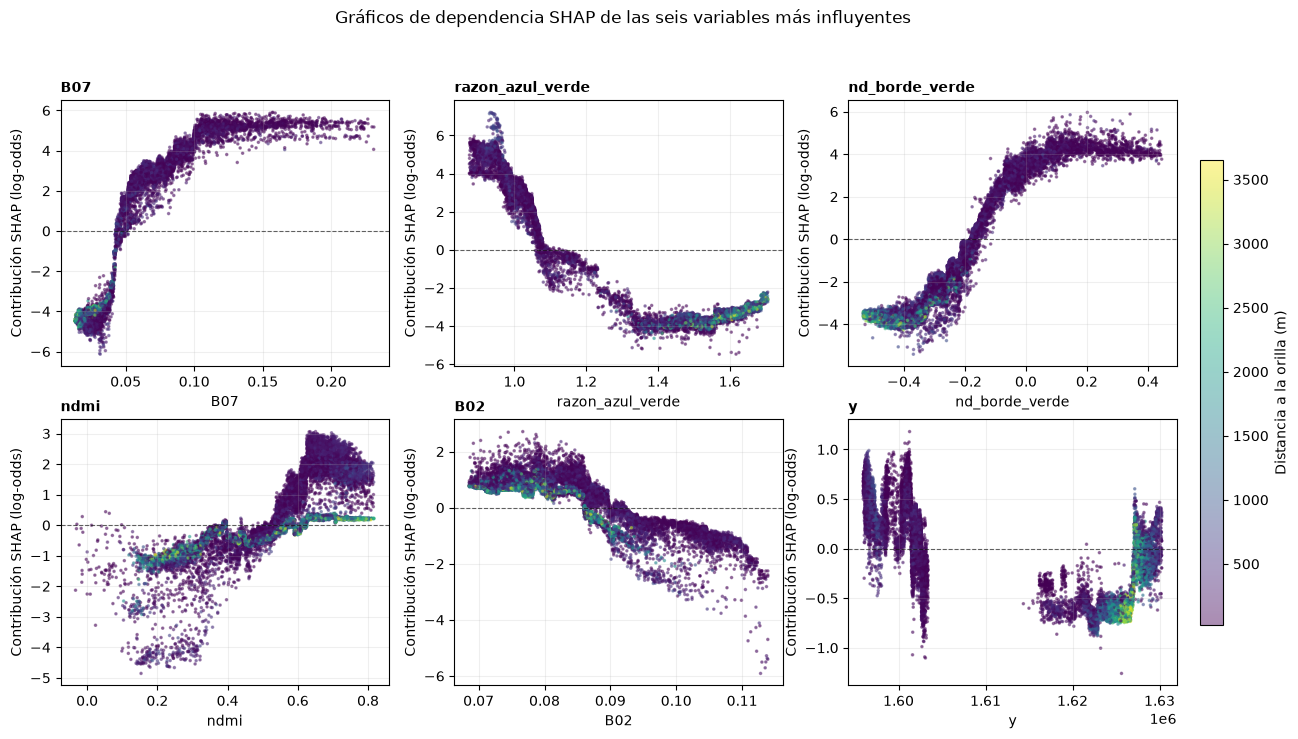

In [8]:
principales = list(importancia_shap.index[:6])

fig, ejes = plt.subplots(2, 3, figsize=(15, 7.6))

for eje, var in zip(ejes.ravel(), principales):
    j = ml.PREDICTORAS.index(var)
    valores_x = X_shap[var].values
    lo, hi = np.percentile(valores_x, [0.5, 99.5])
    dentro = (valores_x >= lo) & (valores_x <= hi)
    dibujo = eje.scatter(valores_x[dentro], valores_shap[dentro, j],
                         c=X_shap["dist_orilla_m"].values[dentro],
                         s=2.5, alpha=0.45, cmap="viridis")
    eje.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    eje.set_xlabel(var)
    eje.set_ylabel("Contribución SHAP (log-odds)")
    eje.set_title(var, loc="left", fontsize=10, fontweight="bold")
    eje.grid(alpha=0.2)

barra = fig.colorbar(dibujo, ax=ejes, fraction=0.02, pad=0.02)
barra.set_label("Distancia a la orilla (m)")

fig.suptitle("Gráficos de dependencia SHAP de las seis variables más influyentes", y=1.0)
plt.show()

In [9]:
print("Dirección del efecto: SHAP medio en el quintil bajo y en el quintil alto\n")
print(f"{'variable':<18}{'SHAP q1 (valores bajos)':>25}{'SHAP q5 (valores altos)':>26}{'dirección':>14}")
print("-" * 83)

for var in importancia_shap.index[:8]:
    j = ml.PREDICTORAS.index(var)
    valores_x = X_shap[var].values
    q1, q5 = np.percentile(valores_x, [20, 80])
    shap_bajo = valores_shap[valores_x <= q1, j].mean()
    shap_alto = valores_shap[valores_x >= q5, j].mean()
    flecha = "↑ aumenta" if shap_alto > shap_bajo else "↓ disminuye"
    print(f"{var:<18}{shap_bajo:>25.3f}{shap_alto:>26.3f}{flecha:>14}")

Dirección del efecto: SHAP medio en el quintil bajo y en el quintil alto

variable            SHAP q1 (valores bajos)   SHAP q5 (valores altos)     dirección
-----------------------------------------------------------------------------------
B07                                  -4.406                     4.675     ↑ aumenta
razon_azul_verde                      4.611                    -3.283   ↓ disminuye
nd_borde_verde                       -3.675                     3.779     ↑ aumenta
ndmi                                 -1.181                     1.525     ↑ aumenta
B02                                   0.805                    -1.167   ↓ disminuye
y                                     0.386                    -0.152   ↓ disminuye
B08                                  -0.108                    -0.462   ↓ disminuye
mndwi                                -0.093                     0.310     ↑ aumenta


In [10]:
# El modelo trabaja sobre dos lagos con opticas distintas. Vale la pena mirar si
# se apoya en las mismas variables en cada uno.
lago_shap = prueba.loc[muestra_shap, "lago"].values

print("SHAP medio absoluto por lago (¿usa el modelo las mismas variables en ambos?)\n")
comparativa = pd.DataFrame({
    lago: np.abs(valores_shap[lago_shap == lago]).mean(axis=0)
    for lago in ["Atitlan", "Amatitlan"]
}, index=ml.PREDICTORAS)
comparativa["diferencia"] = comparativa["Amatitlan"] - comparativa["Atitlan"]
print(comparativa.sort_values("Amatitlan", ascending=False).round(3).to_string())

SHAP medio absoluto por lago (¿usa el modelo las mismas variables en ambos?)

                  Atitlan  Amatitlan  diferencia
B07                 4.185      3.314      -0.870
razon_azul_verde    3.527      3.276      -0.251
nd_borde_verde      3.527      2.423      -1.103
ndmi                0.494      1.561       1.067
B02                 0.718      0.982       0.264
mndwi               0.201      0.474       0.273
B08                 0.256      0.465       0.209
x                   0.192      0.435       0.243
B03                 0.239      0.424       0.185
B8A                 0.198      0.391       0.193
B12                 0.244      0.358       0.114
y                   0.458      0.335      -0.123
ndwi                0.301      0.311       0.009
B11                 0.116      0.267       0.151
dist_orilla_m       0.347      0.246      -0.101
brillo_visible      0.276      0.211      -0.065


## 8.3 y 8.4 Qué significan estos patrones

### Las tres variables dominantes miden clorofila, cada una a su manera

| Variable | Dirección | SHAP en valores bajos → altos | Lectura física |
|---|---|---|---|
| `B07` | ↑ aumenta | −4.406 → +4.675 | Reflectancia en el borde rojo (783 nm) |
| `razon_azul_verde` | ↓ **disminuye** | +4.611 → −3.283 | B02/B03, razón azul/verde |
| `nd_borde_verde` | ↑ aumenta | −3.675 → +3.779 | Contraste borde rojo contra verde |
| `ndmi` | ↑ aumenta | −1.181 → +1.525 | Contraste infrarrojo cercano / onda corta |
| `B02` | ↓ disminuye | +0.805 → −1.167 | Reflectancia en el azul (490 nm) |

**El realce en el borde rojo es el mecanismo principal, y el signo es el correcto.** El
agua limpia absorbe casi toda la luz a partir de los 700 nm. Cuando hay una concentración
alta de clorofila-a, la dispersión de las células y la fluorescencia del pigmento
levantan un pico de reflectancia justo en el borde rojo. `B07` alto empuja con fuerza
hacia "alta presencia" (+4.675 de log-odds) y `B07` bajo empuja con la misma fuerza en
sentido contrario (−4.406). Es exactamente el fenómeno en el que se apoya el NDCI del que
salió la etiqueta, medido con otra banda.

**La razón azul/verde va en sentido contrario, y también es lo correcto.** La clorofila-a
absorbe con fuerza en el azul y refleja en el verde. Cuanto más pigmento hay, más baja
B02 y más sube B03, así que la razón B02/B03 **cae**. El modelo aprendió que valores
altos de `razon_azul_verde` —agua azul, poco pigmento— empujan hacia "baja presencia"
(+4.611 en el quintil bajo de la variable frente a −3.283 en el alto). Este es el
principio de los algoritmos de color del océano que se usan desde los años setenta, y el
modelo lo redescubrió sin que nadie se lo dijera. `B02` por separado confirma la misma
dirección.

**`ndmi` es la variable que separa algas de sedimento.** Es $(B08-B11)/(B08+B11)$, y su
efecto es positivo: valores altos empujan hacia alta presencia. El agua absorbe el
infrarrojo de onda corta pase lo que pase, mientras que la biomasa flotando en superficie
refleja en el infrarrojo cercano. Una nata de cianobacteria sube B08 sin subir B11 y
dispara el índice; una carga de sedimento mineral sube las dos y lo deja quieto. El
modelo usa `ndmi` precisamente para no confundir agua turbia con agua con algas.

### El modelo no usa las mismas variables en los dos lagos

La tabla por lago es el resultado más interesante del cuaderno:

| Variable | SHAP medio en Atitlán | SHAP medio en Amatitlán | Diferencia |
|---|---|---|---|
| `B07` | 4.185 | 3.314 | −0.870 |
| `nd_borde_verde` | 3.527 | 2.423 | −1.103 |
| `ndmi` | 0.494 | **1.561** | **+1.067** |
| `B02` | 0.718 | 0.982 | +0.264 |

En **Atitlán** el modelo se apoya casi por completo en el borde rojo. Tiene sentido: es
agua oligotrófica, muy clara, con 1.24 µg/L de clorofila media. Sobre ese fondo limpio
cualquier realce en el borde rojo es señal, sin nada que lo enmascare.

En **Amatitlán** el peso del borde rojo baja y el de `ndmi` se triplica. Ahí el agua
recibe la descarga del río Villalobos y lleva sedimento mineral en suspensión, que también
levanta la reflectancia. El borde rojo por sí solo se vuelve ambiguo, y el modelo necesita
el contraste infrarrojo para decidir si lo que ve es biomasa o barro.

Esto encaja de forma independiente con lo que había encontrado la Parte I por otro camino:
que el NDWI predice la clorofila en Atitlán (r = −0.955) y no en Amatitlán (r = −0.348,
p = 0.29), porque el sedimento compite por la señal óptica. Dos análisis distintos, sobre
métodos distintos, llegando a la misma conclusión física.

También explica en parte por qué el Experimento A del cuaderno 11 falló: un modelo
entrenado solo en Atitlán aprende a interpretar el borde rojo sobre agua limpia y nunca
tuvo que aprender a descontar sedimento, así que al llegar a Amatitlán interpreta mal el
agua turbia.

### La advertencia que no hay que perder de vista

Todo lo anterior confirma que el modelo aprendió física óptica del agua correcta y no
correlaciones espurias. Pero conviene recordar de dónde viene la etiqueta: es un umbral
sobre un índice calculado con B04 y B05. Que el modelo reconstruya esa etiqueta apoyándose
en B07, B02 y B03 demuestra que las bandas del espectro del agua son coherentes entre sí
—que es un resultado real y no trivial— pero **no** demuestra que detectaría una floración
que el índice de la Parte I no hubiera detectado.

Dicho de otro modo: el modelo aprendió a leer el espectro del agua igual que lo lee el
índice CyanoLakes. Si el índice se equivoca en una situación concreta, el modelo se
equivocará igual, y con la misma confianza. Esto se retoma en el cuaderno 14.

In [11]:
joblib.dump({"ganancia": ganancia, "permutacion": permutacion,
             "shap_medio": importancia_shap, "por_lago": comparativa},
            config.MODELOS / "interpretabilidad.joblib")
print("Resultados de interpretabilidad guardados.")

Resultados de interpretabilidad guardados.


---

**Siguiente:** `13_Mapas_Predictivos.ipynb` — mapas de probabilidad por lago y análisis
espacial de los errores (ejercicio 9).